In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json_tricks


In [2]:
inputs = json_tricks.load('inputs/inputs.json')
answer = {
    f'case_{index}': {}
    for index, case in enumerate(inputs)
}

print(inputs[0]['X'].shape)

(506, 4)


# Linear Regression: Geometry, Scaling, and Decorrelation

Linear regression looks simple: choose weights that minimize mean squared error. But the geometry of the feature matrix can make the same optimization problem either friendly or painfully slow.

In this task we will use the Boston housing-price dataset, the classic dataset formerly available as `sklearn.datasets.load_boston`. We store the generated test samples in single precision to make numerical fragility visible. We select features with non-zero means, non-unit variances, and awkward geometry. We will solve linear regression analytically with the explicit MSE solution, trace gradient descent, and then repair the geometry by decorrelating or at least normalizing the features.


# Task 1. Dataset and Mean Squared Error

The dataset has deliberately awkward feature scales. Before solving anything, implement helpers for the linear model and MSE loss.

Implement the functions below:

- `add_bias_column(X)`: return a matrix with a bias column with a column of ones inserted before the original feature columns.
- `predict_linear(X_one, weights)`: return the vector of predictions `X_one @ weights`.
- `mse_loss(X_one, weights, y)`: return the mean squared error between predictions and targets.

The input arrays already carry the intended numeric precision, so the functions should implement the formulas directly.


In [5]:
def add_bias_column(X):
    # Создаем столбец единиц той же точности, что и X
    ones = np.ones((X.shape[0], 1), dtype=X.dtype)

    # Добавляем bias-столбец перед исходными признаками
    return np.concatenate([ones, X], axis=1)    


def predict_linear(X_one, weights):
    return X_one @ weights


def mse_loss(X_one, weights, y):
    y_pred = predict_linear(X_one, weights)    
    return np.mean((y_pred - y) ** 2)


# Check 1. Dataset Shape and Feature Scales

The bars show that the selected features are not centered and do not have unit variance.


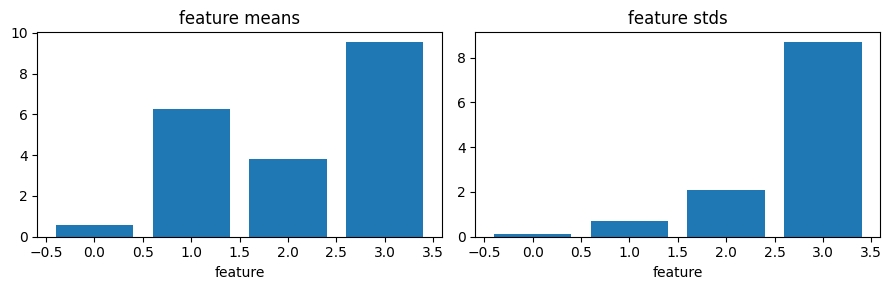

feature means: [0.55469507 6.284634   3.7950428  9.549407  ]
feature stds: [0.11576312 0.70192254 2.1036284  8.698651  ]


In [6]:
case0 = inputs[0]
X = case0['X']
y = case0['y']
X_one = add_bias_column(X)
two_feature_indices = [0, 3]
zero_weights = np.zeros(X_one.shape[1], dtype=X_one.dtype)

np.testing.assert_equal(X_one.shape, (X.shape[0], X.shape[1] + 1))
np.testing.assert_allclose(X_one[:, 0], np.ones(X.shape[0], dtype=X.dtype))
np.testing.assert_allclose(predict_linear(X_one, zero_weights), np.zeros(X.shape[0], dtype=X.dtype))
np.testing.assert_allclose(mse_loss(X_one, zero_weights, y), mse_loss(X_one, zero_weights, y))

feature_means = X.mean(axis=0)
feature_stds = X.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(np.arange(X.shape[1]), feature_means)
axes[0].set_title('feature means')
axes[0].set_xlabel('feature')
axes[1].bar(np.arange(X.shape[1]), feature_stds)
axes[1].set_title('feature stds')
axes[1].set_xlabel('feature')
plt.tight_layout()
plt.show()

for index, case in enumerate(inputs):
    X_case_one = add_bias_column(case['X'])
    y_case = case['y']
    answer[f'case_{index}']['raw_one_shape'] = np.array(X_case_one.shape)
    answer[f'case_{index}']['raw_feature_means'] = case['X'].mean(axis=0)
    answer[f'case_{index}']['raw_feature_stds'] = case['X'].std(axis=0)
    answer[f'case_{index}']['zero_loss'] = mse_loss(X_case_one, np.zeros(X_case_one.shape[1], dtype=X_case_one.dtype), y_case)

print('feature means:', feature_means)
print('feature stds:', feature_stds)


# Task 2. MSE Solution

For linear regression with MSE, the weights that minimize the training loss can be computed directly from the feature matrix and target vector.

Implement the functions below:

- `mse_solution(X_one, y)`: form `X_one.T @ X_one`, form `X_one.T @ y`, and return the weights that minimize MSE.
- `gram_eigenvalues(X_one)`: return the eigenvalues of `X_one.T @ X_one`; these values will be used to diagnose ill-conditioning.

The raw matrix is ill-conditioned, so the weights are a bad numerical representation of the same model even when the loss is low.


In [7]:
def mse_solution(X_one, y):
    XTX = X_one.T @ X_one

    # Right-hand side: X^T y
    XTy = X_one.T @ y

    # Solve normal equations:
    # (X^T X) w = X^T y
    weights = np.linalg.solve(XTX, XTy)
    return weights


def gram_eigenvalues(X_one):
    # Gram matrix: X^T X
    XTX = X_one.T @ X_one

    # Since X^T X is symmetric, use eigvalsh
    eigenvalues = np.linalg.eigvalsh(XTX)

    return eigenvalues


# Check 2. Raw MSE Solution Weights

The direct MSE solution reaches a low training loss here, but on raw nitric-oxide, room-count, distance, and highway-access scales the matrix is ill-conditioned. This is what we mean here by bad weights: the computation amplifies small numerical and data perturbations, so the coefficients are not a comfortable representation.

With single-precision inputs, the damage is no longer just theoretical: the Gram matrix and right-hand side are rounded before the weights are computed.

Even the pseudo-inverse is not a magic escape hatch. It is usually much safer than the explicit inverse because it is based on the SVD, but if `X.T @ X` is extremely ill-conditioned, the data are rounded, or the smallest singular directions still carry target signal, then `np.linalg.pinv(X) @ y` can also return unstable coefficients.


(506, 5) (506,)


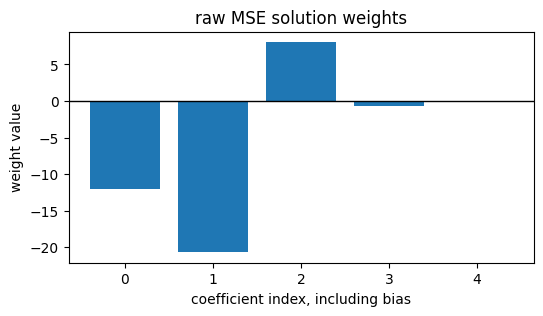

MSE solution weights: [-12.020745   -20.676472     8.030497    -0.7093018   -0.18370059]
MSE solution loss: 36.83295


In [8]:
print(X_one.shape, y.shape)
mse_raw = mse_solution(X_one, y)
mse_raw_loss = mse_loss(X_one, mse_raw, y)

np.testing.assert_equal(mse_raw.shape, (X_one.shape[1],))
np.testing.assert_allclose(mse_raw_loss, np.min([mse_raw_loss, mse_loss(X_one, zero_weights, y)]) , atol=1e-2)

plt.figure(figsize=(6, 3))
plt.bar(np.arange(len(mse_raw)), mse_raw)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('coefficient index, including bias')
plt.ylabel('weight value')
plt.title('raw MSE solution weights')
plt.show()

for index, case in enumerate(inputs):
    X_case_one = add_bias_column(case['X'])
    y_case = case['y']
    w = mse_solution(X_case_one, y_case)
    answer[f'case_{index}']['raw_mse_solution_weights'] = w
    answer[f'case_{index}']['raw_mse_solution_loss'] = mse_loss(X_case_one, w, y_case)

print('MSE solution weights:', mse_raw)
print('MSE solution loss:', mse_raw_loss)


# Task 3. Two-Feature Loss Geometry and Gradient Descent

Now keep only features 0 and 3. You will implement the actual MSE gradient and the full gradient descent loop for a linear model with a bias and two feature weights.

The check cell visualizes two related things:

- the loss geometry over the two feature weights, with the bias fixed to the MSE solution bias, so that the contour plot is genuinely two-dimensional;
- the loss history of the full gradient descent update, where the bias and both feature weights are updated together.

Implement the functions below:

- `gradient_of_mse(X_one, weights, y)`: return the gradient of MSE with respect to the weights, using `2 * X_one.T @ residual / n`.
- `gradient_descent(X_one, y, initial_weights, learning_rate, n_steps)`: repeatedly update the weights by subtracting `learning_rate * gradient`, and return both the full weight history and the loss history.

The returned history arrays should include the initial weights and initial loss before any update.


In [9]:
def gradient_of_mse(X_one, weights, y):
    # residual = predictions - targets
    residual = X_one @ weights - y

    n = X_one.shape[0]

    # Gradient of MSE:
    gradient = 2 * X_one.T @ residual / n

    return gradient


def gradient_descent(X_one, y, initial_weights, learning_rate, n_steps):
    # Current weights
    weights = initial_weights.copy()

    weight_history = np.zeros(
        (n_steps + 1, initial_weights.shape[0]),
        dtype=initial_weights.dtype
    )

    loss_history = np.zeros(
        n_steps + 1,
        dtype=initial_weights.dtype
    )

    weight_history[0] = weights
    residual = X_one @ weights - y
    loss_history[0] = np.mean(residual ** 2)

    for step in range(n_steps):
        gradient = gradient_of_mse(X_one, weights, y)
        weights = weights - learning_rate * gradient
        weight_history[step + 1] = weights
        residual = X_one @ weights - y
        loss_history[step + 1] = np.mean(residual ** 2)

    return weight_history, loss_history
    return np.zeros((n_steps + 1, initial_weights.shape[0]), dtype=initial_weights.dtype), np.zeros(n_steps + 1, dtype=initial_weights.dtype)


In [10]:
def gradient_descent_on_two_weight_slice(X_one, y, initial_weights, learning_rate, n_steps):
    weights = initial_weights.copy()
    fixed_bias = weights[0]
    weight_history = [weights.copy()]
    loss_history = [mse_loss(X_one, weights, y)]
    for _ in range(n_steps):
        gradient = gradient_of_mse(X_one, weights, y)
        gradient[0] = 0
        weights = weights - learning_rate * gradient
        weights[0] = fixed_bias
        weight_history.append(weights.copy())
        loss_history.append(mse_loss(X_one, weights, y))
    return np.array(weight_history), np.array(loss_history)


def loss_grid_for_two_weights(X_two_one, y, bias, w1_range, w2_range):
    W1, W2 = np.meshgrid(w1_range, w2_range)
    losses = np.zeros_like(W1)
    x1 = X_two_one[:, 1]
    x2 = X_two_one[:, 2]
    for row in range(W1.shape[0]):
        for col in range(W1.shape[1]):
            w1 = W1[row, col]
            w2 = W2[row, col]
            weights = np.array([bias, w1, w2], dtype=X_two_one.dtype)
            losses[row, col] = mse_loss(X_two_one, weights, y)
    return W1, W2, losses


def plot_two_weight_geometry(X_two_one, y, optimum, history, title):
    w1_values = np.concatenate([history[:, 1], [optimum[1]]])
    w2_values = np.concatenate([history[:, 2], [optimum[2]]])
    span1 = max(5.0, 0.15 * (w1_values.max() - w1_values.min()))
    span2 = max(5.0, 0.15 * (w2_values.max() - w2_values.min()))
    w1_range = np.linspace(w1_values.min() - span1, w1_values.max() + span1, 100)
    w2_range = np.linspace(w2_values.min() - span2, w2_values.max() + span2, 100)
    bias = optimum[0]
    W1, W2, losses = loss_grid_for_two_weights(X_two_one, y, bias, w1_range, w2_range)

    plt.figure(figsize=(6, 5))
    levels = np.geomspace(max(losses.min(), 1e-8), losses.max(), 22)
    plt.contour(W1, W2, losses, levels=levels)
    plt.plot(history[:, 1], history[:, 2], color='tab:orange', marker='o', markersize=2, linewidth=1, label='gradient descent trajectory')
    plt.scatter([history[0, 1]], [history[0, 2]], color='tab:blue', label='start')
    plt.scatter([history[-1, 1]], [history[-1, 2]], color='tab:orange', label='final GD weights')
    plt.scatter([optimum[1]], [optimum[2]], color='tab:red', label='MSE solution optimum')
    plt.xlabel('weight for feature 1')
    plt.ylabel('weight for feature 2')
    plt.title(title)
    plt.legend()
    plt.show()


def plot_weight_history(history, title):
    plt.figure(figsize=(6, 3))
    plt.plot(history[:, 0], label='bias')
    plt.plot(history[:, 1], label='weight for feature 1')
    plt.plot(history[:, 2], label='weight for feature 2')
    plt.xlabel('gradient descent step')
    plt.ylabel('weight value')
    plt.title(title)
    plt.legend()
    plt.show()


# Check 3. Raw Two-Feature Contours

The MSE solution is far from the origin in the raw contour plot because the original features have large means and awkward scales. The orange path is drawn on the same fixed-bias two-weight slice as the contours, while the loss curve below shows the behavior of the full gradient descent update implemented in this task.


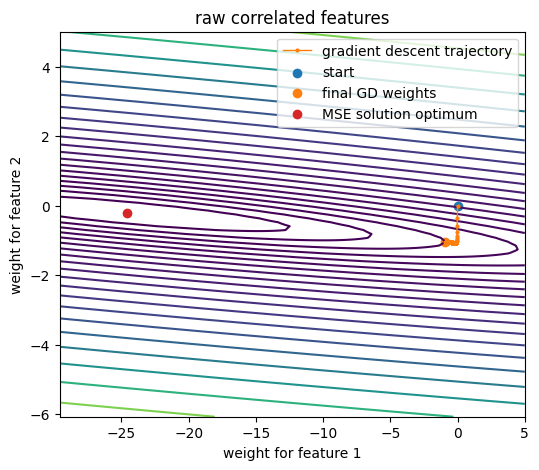

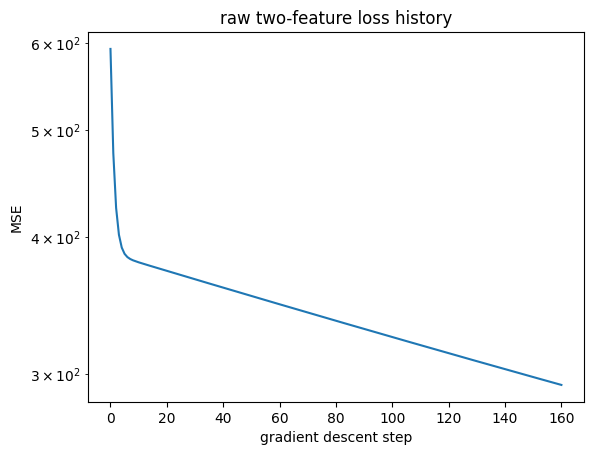

raw two-feature eigenvalues: [3.4489415e+00 2.8119919e+02 8.4813820e+04]
raw two-feature final GD loss: 293.38


In [11]:
X_two_raw = X[:, two_feature_indices]
X_two_one_raw = add_bias_column(X_two_raw)
w_two_raw = mse_solution(X_two_one_raw, y)
eig_two_raw = gram_eigenvalues(X_two_one_raw)
learning_rate_raw = 0.001
history_raw, loss_history_raw = gradient_descent(
    X_two_one_raw,
    y,
    np.zeros(X_two_one_raw.shape[1], dtype=X_two_one_raw.dtype),
    learning_rate_raw,
    160,
)
slice_history_raw, slice_loss_history_raw = gradient_descent_on_two_weight_slice(
    X_two_one_raw,
    y,
    np.array([w_two_raw[0], 0, 0], dtype=X_two_one_raw.dtype),
    learning_rate_raw,
    160,
)

# np.testing.assert_equal(history_raw.shape, (161, 3))
# np.testing.assert_array_less(loss_history_raw[-1], loss_history_raw[0])

plot_two_weight_geometry(X_two_one_raw, y, w_two_raw, slice_history_raw, 'raw correlated features')
plt.plot(loss_history_raw)
plt.yscale('log')
plt.xlabel('gradient descent step')
plt.ylabel('MSE')
plt.title('raw two-feature loss history')
plt.show()

for index, case in enumerate(inputs):
    X_two = case['X'][:, two_feature_indices]
    X_case_one = add_bias_column(X_two)
    y_case = case['y']
    hist, losses = gradient_descent(X_case_one, y_case, np.zeros(X_case_one.shape[1], dtype=X_case_one.dtype), learning_rate_raw, 160)
    answer[f'case_{index}']['raw_two_feature_mse_solution_weights'] = mse_solution(X_case_one, y_case)
    answer[f'case_{index}']['raw_two_feature_gd_final_weights'] = hist[-1]
    answer[f'case_{index}']['raw_two_feature_loss_history'] = losses

print('raw two-feature eigenvalues:', eig_two_raw)
print('raw two-feature final GD loss:', loss_history_raw[-1])


# Why Is Raw Gradient Descent Slow?

For MSE, the curvature of the loss is controlled by $X^T X$. Its eigenvectors are the main axes of the quadratic bowl, and its eigenvalues say how steep the bowl is along those axes.

When one eigenvalue is huge and another is tiny, the contours become a long narrow valley. A learning rate small enough not to explode in the steep direction is too small to move quickly in the flat direction. This is why raw correlated features make gradient descent crawl.


# Task 4. Decorrelation by Whitening

Decorrelation rotates and rescales centered features so their covariance matrix becomes close to identity. In this coordinate system the loss contours are much rounder.

Implement `decorrelate_features(X)` so that it returns three objects:

- `X_decorrelated`: centered and whitened features.
- `mean`: the row vector of feature means used for centering.
- `whitening`: the whitening matrix used to transform centered data.

Whitening is the following process:

- First center the features: $X_c = X - \mu$.
- Compute the covariance matrix $C = X_c^T X_c / n$.
- It is a symmetric positive semi-definite matrix, so it has the eigendecomposition $C = Q \Lambda Q^T$.
- In this form, $Q$ is an orthogonal matrix whose columns are eigenvectors of $C$, and $\Lambda = \operatorname{diag}(\lambda_1, \ldots, \lambda_d)$ is a diagonal matrix whose diagonal entries are the corresponding eigenvalues.
- We want transformed features $\tilde X$ whose covariance is close to identity: $\tilde X^T \tilde X / n \approx I$.
- Use a transform of the form $\tilde X = X_c A$.
- With $A = Q(\Lambda + \varepsilon I)^{-1/2}Q^T$, we get the desired whitening transform up to the small numerical stabilizer $\varepsilon$.
- The stabilizer prevents division by zero or by extremely tiny eigenvalues; use `1e-6`.

Hint: use `np.linalg.eigh` on the covariance matrix.


In [12]:
def decorrelate_features(X):
    eps = 1e-6

    # 1. Center features: X_c = X - mu
    mean = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mean

    # 2. Covariance matrix: C = X_c^T X_c / n
    n = X.shape[0]
    C = X_centered.T @ X_centered / n

    # 3. Eigendecomposition: C = Q Λ Q^T
    eigenvalues, Q = np.linalg.eigh(C)

    # 4. Whitening matrix:
    # A = Q (Λ + eps I)^(-1/2) Q^T
    inv_sqrt_lambda = np.diag(1.0 / np.sqrt(eigenvalues + eps))
    whitening = Q @ inv_sqrt_lambda @ Q.T

    # 5. Decorrelated / whitened features
    X_decorrelated = X_centered @ whitening

    return X_decorrelated, mean, whitening    


# Check 4. Decorrelated Two-Feature Optimization

After whitening, the transformed features have near-zero mean and covariance close to identity. The MSE solution moves close to the center of the contour plot, and gradient descent reaches the minimum much faster.


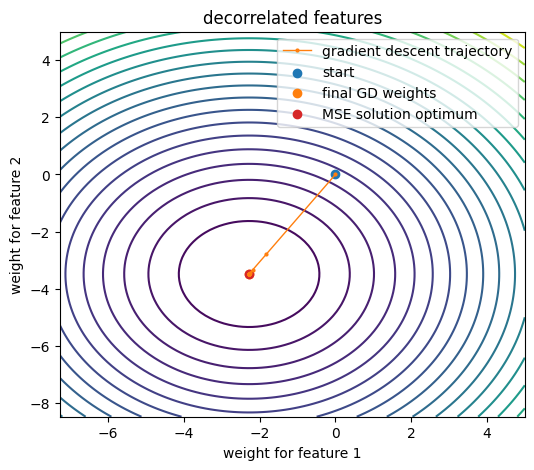

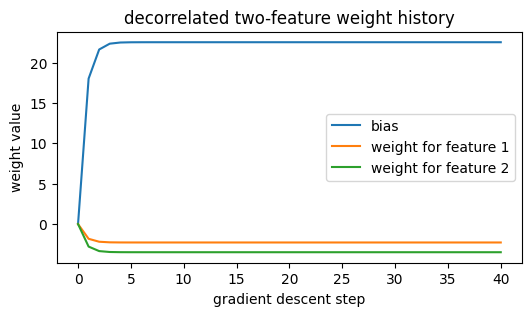

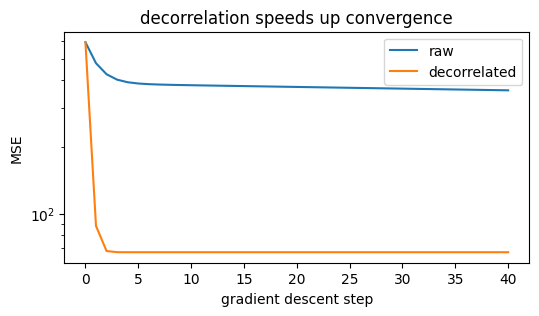

decorrelated eigenvalues: [505.93954 505.99948 506.00003]
decorrelated final GD loss: 67.05163


In [13]:
X_two_decorrelated, mean_two, whitening_two = decorrelate_features(X_two_raw)
X_two_one_decorrelated = add_bias_column(X_two_decorrelated)
w_two_decorrelated = mse_solution(X_two_one_decorrelated, y)
eig_two_decorrelated = gram_eigenvalues(X_two_one_decorrelated)
learning_rate_decorrelated = 0.8 / (2 * eig_two_decorrelated.max() / X_two_one_decorrelated.shape[0])
history_decorrelated, loss_history_decorrelated = gradient_descent(
    X_two_one_decorrelated,
    y,
    np.zeros(X_two_one_decorrelated.shape[1], dtype=X_two_one_decorrelated.dtype),
    learning_rate_decorrelated,
    40,
)
slice_history_decorrelated, slice_loss_history_decorrelated = gradient_descent_on_two_weight_slice(
    X_two_one_decorrelated,
    y,
    np.array([w_two_decorrelated[0], 0, 0], dtype=X_two_one_decorrelated.dtype),
    learning_rate_decorrelated,
    40,
)

np.testing.assert_allclose(X_two_decorrelated.mean(axis=0), np.zeros(2), atol=5e-3)
np.testing.assert_allclose(np.cov(X_two_decorrelated, rowvar=False, bias=True), np.eye(2), atol=6e-2)
np.testing.assert_array_less(loss_history_decorrelated[-1], loss_history_raw[-1])

plot_two_weight_geometry(X_two_one_decorrelated, y, w_two_decorrelated, slice_history_decorrelated, 'decorrelated features')
plot_weight_history(history_decorrelated, 'decorrelated two-feature weight history')
plt.figure(figsize=(6, 3))
plt.plot(loss_history_raw[:41], label='raw')
plt.plot(loss_history_decorrelated, label='decorrelated')
plt.yscale('log')
plt.xlabel('gradient descent step')
plt.ylabel('MSE')
plt.title('decorrelation speeds up convergence')
plt.legend()
plt.show()

for index, case in enumerate(inputs):
    X_two = case['X'][:, two_feature_indices]
    X_decorrelated, mean, whitening = decorrelate_features(X_two)
    X_case_one = add_bias_column(X_decorrelated)
    y_case = case['y']
    eig = gram_eigenvalues(X_case_one)
    lr = 0.8 / (2 * eig.max() / X_case_one.shape[0])
    hist, losses = gradient_descent(X_case_one, y_case, np.zeros(X_case_one.shape[1], dtype=X_case_one.dtype), lr, 40)
    answer[f'case_{index}']['decorrelated_two_feature_mse_solution_weights'] = mse_solution(X_case_one, y_case)
    answer[f'case_{index}']['decorrelated_two_feature_gd_final_weights'] = hist[-1]
    answer[f'case_{index}']['decorrelated_two_feature_loss_history'] = losses
    answer[f'case_{index}']['decorrelated_two_feature_eigenvalues'] = eig
    answer[f'case_{index}']['decorrelated_covariance'] = np.cov(X_decorrelated, rowvar=False, bias=True)

print('decorrelated eigenvalues:', eig_two_decorrelated)
print('decorrelated final GD loss:', loss_history_decorrelated[-1])


# Task 5. Poor Man's Decorrelation: Centering and Normalization

Whitening is very effective, but a simpler baseline often works well: subtract the mean and divide by the standard deviation feature by feature. This does not remove all correlation, but it fixes the most painful scale problem.

Implement `normalize_features(X)` so that it returns three objects:

- `X_normalized`: each feature centered and divided by its own standard deviation.
- `mean`: the row vector of feature means.
- `std`: the row vector of feature standard deviations.

Add `1e-3` to the denominator so division stays safe when a feature has almost no variation.


In [14]:
def normalize_features(X):
    mean = np.mean(X, axis=0, keepdims=True)
    std = np.std(X, axis=0, keepdims=True)
    X_normalized = (X - mean) / (std + 1e-3)
    return X_normalized, mean, std


# Check 5. Normalized Two-Feature Optimization

Even without full whitening, centering and normalization make the contours easier and gradient descent behaves well.


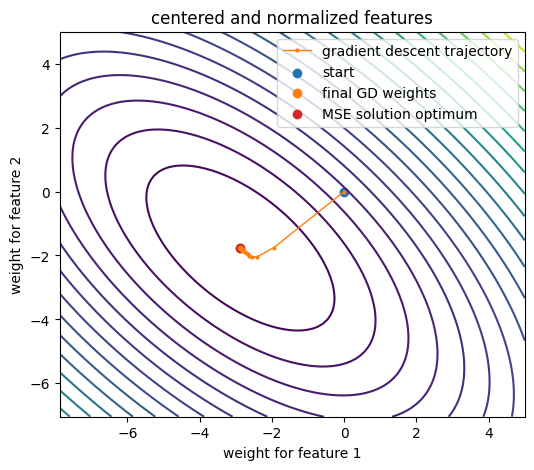

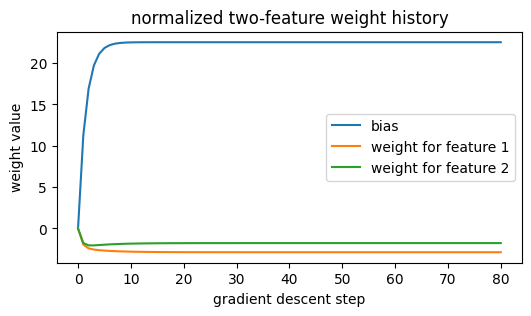

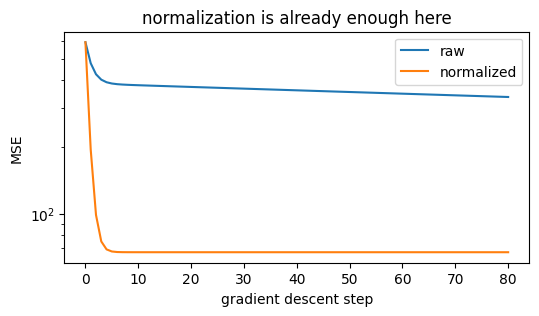

normalized eigenvalues: [194.8929 506.     808.3597]
normalized final GD loss: 67.05163


In [15]:
X_two_normalized, mean_norm_two, std_norm_two = normalize_features(X_two_raw)
X_two_one_normalized = add_bias_column(X_two_normalized)
w_two_normalized = mse_solution(X_two_one_normalized, y)
eig_two_normalized = gram_eigenvalues(X_two_one_normalized)
learning_rate_normalized = 0.8 / (2 * eig_two_normalized.max() / X_two_one_normalized.shape[0])
history_normalized, loss_history_normalized = gradient_descent(
    X_two_one_normalized,
    y,
    np.zeros(X_two_one_normalized.shape[1], dtype=X_two_one_normalized.dtype),
    learning_rate_normalized,
    80,
)
slice_history_normalized, slice_loss_history_normalized = gradient_descent_on_two_weight_slice(
    X_two_one_normalized,
    y,
    np.array([w_two_normalized[0], 0, 0], dtype=X_two_one_normalized.dtype),
    learning_rate_normalized,
    80,
)

np.testing.assert_allclose(X_two_normalized.mean(axis=0), np.zeros(2), atol=5e-3)
np.testing.assert_allclose(X_two_normalized.std(axis=0), np.ones(2), atol=1e-2)
np.testing.assert_array_less(loss_history_normalized[-1], loss_history_raw[-1])

plot_two_weight_geometry(X_two_one_normalized, y, w_two_normalized, slice_history_normalized, 'centered and normalized features')
plot_weight_history(history_normalized, 'normalized two-feature weight history')
plt.figure(figsize=(6, 3))
plt.plot(loss_history_raw[:81], label='raw')
plt.plot(loss_history_normalized, label='normalized')
plt.yscale('log')
plt.xlabel('gradient descent step')
plt.ylabel('MSE')
plt.title('normalization is already enough here')
plt.legend()
plt.show()

for index, case in enumerate(inputs):
    X_two = case['X'][:, two_feature_indices]
    X_normalized, mean, std = normalize_features(X_two)
    X_case_one = add_bias_column(X_normalized)
    y_case = case['y']
    eig = gram_eigenvalues(X_case_one)
    lr = 0.8 / (2 * eig.max() / X_case_one.shape[0])
    hist, losses = gradient_descent(X_case_one, y_case, np.zeros(X_case_one.shape[1], dtype=X_case_one.dtype), lr, 80)
    answer[f'case_{index}']['normalized_two_feature_mse_solution_weights'] = mse_solution(X_case_one, y_case)
    answer[f'case_{index}']['normalized_two_feature_gd_final_weights'] = hist[-1]
    answer[f'case_{index}']['normalized_two_feature_loss_history'] = losses
    answer[f'case_{index}']['normalized_two_feature_eigenvalues'] = eig

print('normalized eigenvalues:', eig_two_normalized)
print('normalized final GD loss:', loss_history_normalized[-1])


# Task 6. Return to All Features

Finally, normalize every feature and fit the full linear regression model. No new function is required here: reuse `normalize_features`, `add_bias_column`, `mse_solution`, and `gradient_descent` on all columns of `X`.

The practical rule of thumb is: for linear regression and gradient descent, decorrelate features if you can, and at least center and normalize them.


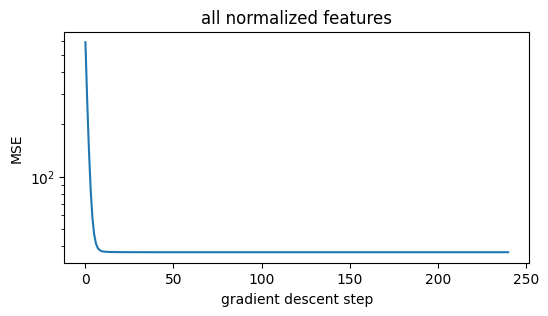

all-feature normalized MSE solution loss: 36.832954
all-feature normalized final GD loss: 36.83295


In [16]:
X_all_normalized, mean_all, std_all = normalize_features(X)
X_all_one_normalized = add_bias_column(X_all_normalized)
w_all_normalized = mse_solution(X_all_one_normalized, y)
eig_all_normalized = gram_eigenvalues(X_all_one_normalized)
learning_rate_all = 0.8 / (2 * eig_all_normalized.max() / X_all_one_normalized.shape[0])
history_all_normalized, loss_history_all_normalized = gradient_descent(
    X_all_one_normalized,
    y,
    np.zeros(X_all_one_normalized.shape[1], dtype=X_all_one_normalized.dtype),
    learning_rate_all,
    240,
)

np.testing.assert_allclose(X_all_normalized.mean(axis=0), np.zeros(X.shape[1]), atol=5e-3)
np.testing.assert_allclose(X_all_normalized.std(axis=0), np.ones(X.shape[1]), atol=1e-2)
np.testing.assert_allclose(loss_history_all_normalized[-1], mse_loss(X_all_one_normalized, w_all_normalized, y), atol=5e-1)

plt.figure(figsize=(6, 3))
plt.plot(loss_history_all_normalized)
plt.yscale('log')
plt.xlabel('gradient descent step')
plt.ylabel('MSE')
plt.title('all normalized features')
plt.show()

for index, case in enumerate(inputs):
    X_normalized, mean, std = normalize_features(case['X'])
    X_case_one = add_bias_column(X_normalized)
    y_case = case['y']
    eig = gram_eigenvalues(X_case_one)
    lr = 0.8 / (2 * eig.max() / X_case_one.shape[0])
    hist, losses = gradient_descent(X_case_one, y_case, np.zeros(X_case_one.shape[1], dtype=X_case_one.dtype), lr, 240)
    w = mse_solution(X_case_one, y_case)
    answer[f'case_{index}']['all_normalized_mse_solution_weights'] = w
    answer[f'case_{index}']['all_normalized_mse_solution_loss'] = mse_loss(X_case_one, w, y_case)
    answer[f'case_{index}']['all_normalized_gd_final_weights'] = hist[-1]
    answer[f'case_{index}']['all_normalized_loss_history'] = losses
    answer[f'case_{index}']['all_normalized_eigenvalues'] = eig

print('all-feature normalized MSE solution loss:', mse_loss(X_all_one_normalized, w_all_normalized, y))
print('all-feature normalized final GD loss:', loss_history_all_normalized[-1])


# Takeaway

Raw linear regression can have a perfectly valid mathematical optimum and still be a poor optimization problem. The eigenvalues of $X^T X$ reveal the geometry: very different eigenvalues mean long narrow contours and slow gradient descent.

Decorrelation fixes the geometry directly. Centering and normalization are a cheaper approximation, and in many practical cases they are enough. For linear regression to work reliably with gradient-based optimization, decorrelate the features when possible, and at least normalize them.


In [ ]:
json_tricks.dump(answer, '.answer.json')
